# OSMnx Road Network Exploration

This notebook builds and evaluates a road-network routing workflow for emergency-routing analysis in Geelong.

Current workflow:

1. Download and persist a drivable OSM road graph.
2. Inspect graph structure and edge attributes.
3. Map origin and destination points to nearest network nodes.
4. Compute routes using Dijkstra and A*.
5. Visualize and save route maps.
6. Compare route distance and runtime, then export a summary table.

## Step 1: Import libraries and build the road graph

This cell imports the core tools used in the notebook:

- `osmnx` for downloading and manipulating road networks from OpenStreetMap.
- `networkx` for graph data structures and routing operations.
- `matplotlib` for plotting.

It then enables console logging and caching in OSMnx, defines the place name, and downloads a drivable street network for Geelong. The printed node and edge counts give a quick sense of graph size.

In [66]:
import os
import osmnx as ox
import networkx as nx
import matplotlib.pyplot as plt

ox.settings.log_console = True
ox.settings.use_cache = True

os.makedirs("../outputs/graphs", exist_ok=True)
os.makedirs("../outputs/maps", exist_ok=True)
os.makedirs("../outputs/tables", exist_ok=True)

place_name = "Geelong, Victoria, Australia"
G = ox.graph_from_place(place_name, network_type="drive")

print(G)
print("Nodes:", len(G.nodes))
print("Edges:", len(G.edges))

MultiDiGraph with 519 nodes and 1091 edges
Nodes: 519
Edges: 1091


## Step 2: Plot the downloaded network

This cell renders the full driving graph so you can visually confirm that the network loaded correctly and covers the intended area.

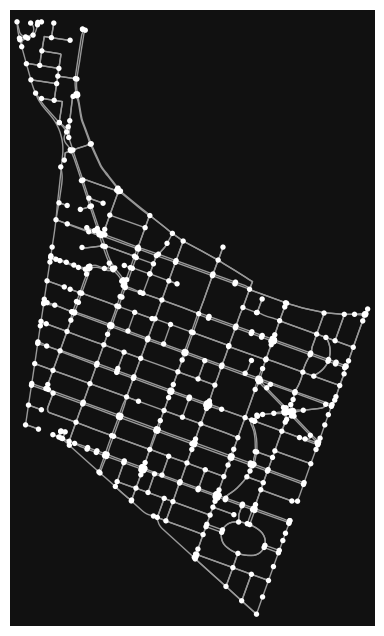

In [67]:
fig, ax = ox.plot_graph(G)
fig.savefig("../outputs/maps/graph_visualization.png", dpi=300, bbox_inches="tight")

## Step 3: Save the graph to disk

This cell stores the network as a GraphML file in [outputs/graphs](../outputs/graphs). That gives you a reusable snapshot of the downloaded network so later steps do not need to query OpenStreetMap again.

In [68]:
ox.save_graphml(G, filepath="../outputs/graphs/geelong.graphml")

## Step 4: Reload the saved graph

This cell loads the GraphML file back into memory. It verifies that the saved network can be read back successfully before doing more analysis.

In [69]:
G = ox.load_graphml("../outputs/graphs/geelong.graphml")
print(G)

MultiDiGraph with 519 nodes and 1091 edges


## Step 5: Recheck graph size

This cell prints the number of nodes and edges again after reloading. That is a simple integrity check to confirm the saved graph still contains the expected structure.

In [70]:
print("Nodes:", len(G.nodes))
print("Edges:", len(G.edges))

Nodes: 519
Edges: 1091


## Step 6: Convert the graph into GeoDataFrames

This cell converts the network graph into two geospatial tables:

- `nodes`: intersection and endpoint records.
- `edges`: road-segment records.

Printing the first few rows helps inspect available attributes before doing filtering, travel-time calculations, or routing logic.

In [71]:
nodes, edges = ox.graph_to_gdfs(G)

print(nodes.head())
print(edges.head())

                  y           x  street_count          highway  \
osmid                                                            
26755988 -38.139261  144.354573             3              NaN   
26755993 -38.146674  144.366688             5  traffic_signals   
26755994 -38.136253  144.352230             3              NaN   
52494741 -38.153391  144.357994             4              NaN   
60278168 -38.149362  144.359788             4              NaN   

                             geometry  
osmid                                  
26755988  POINT (144.35457 -38.13926)  
26755993  POINT (144.36669 -38.14667)  
26755994  POINT (144.35223 -38.13625)  
52494741  POINT (144.35799 -38.15339)  
60278168  POINT (144.35979 -38.14936)  
                                                                     osmid  \
u        v          key                                                      
26755988 870959366  0                                             73498527   
26755993 2337721274 0  

## Step 7: Inspect key graph attributes for routing

These quick checks confirm node coordinates and edge length fields are available before routing.

In [72]:
print(nodes[["x", "y"]].head())

                   x          y
osmid                          
26755988  144.354573 -38.139261
26755993  144.366688 -38.146674
26755994  144.352230 -38.136253
52494741  144.357994 -38.153391
60278168  144.359788 -38.149362


In [73]:
print(edges[["length"]].head())

                             length
u        v          key            
26755988 870959366  0    119.230448
26755993 2337721274 0    114.686524
         263643391  0    288.033251
         266223014  0    227.435745
         9796325331 0     92.433707


In [74]:
print(edges["length"].describe())

count    1091.000000
mean       80.490817
std        71.194043
min         1.145169
25%        15.483949
50%        67.445608
75%       116.556724
max       795.416750
Name: length, dtype: float64


In [75]:
start_lat, start_lon = -38.1499, 144.3617
end_lat, end_lon = -38.1350, 144.3550

## Step 8: Define start and end points and map to network nodes

This section defines origin and destination coordinates, then finds the closest road-network nodes for routing.

In [76]:
start_node = ox.distance.nearest_nodes(G, X=start_lon, Y=start_lat)
end_node = ox.distance.nearest_nodes(G, X=end_lon, Y=end_lat)

print("Start node:", start_node)
print("End node:", end_node)

Start node: 7755711304
End node: 625011962


In [77]:
print("Start node data:", G.nodes[start_node])
print("End node data:", G.nodes[end_node])

Start node data: {'y': -38.1500659, 'x': 144.362252, 'street_count': 4}
End node data: {'y': -38.135483, 'x': 144.3549189, 'street_count': 4}


## Step 9: Visualize start and end nodes

This plot confirms that the chosen origin and destination are mapped correctly on the network.

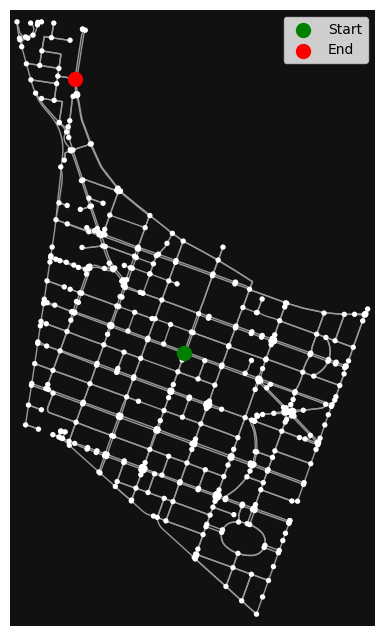

In [78]:
fig, ax = ox.plot_graph(G, show=False, close=False)

ax.scatter(G.nodes[start_node]["x"], G.nodes[start_node]["y"], c="green", s=100, label="Start")
ax.scatter(G.nodes[end_node]["x"], G.nodes[end_node]["y"], c="red", s=100, label="End")

ax.legend()
plt.show()
fig.savefig("../outputs/maps/start_end_nodes.png", dpi=300, bbox_inches="tight")

## Step 10: Compute Dijkstra shortest path

This step computes a shortest path by edge length using Dijkstra and reports a quick route summary.

In [79]:
route = nx.shortest_path(
    G,
    source=start_node,
    target=end_node,
    weight="length",
    method="dijkstra"
)

print("Route found.")
print("Number of nodes in route:", len(route))
print("First 10 nodes in route:", route[:10])

Route found.
Number of nodes in route: 16
First 10 nodes in route: [7755711304, 7755711303, 266090781, 317727339, 3606643577, 3606643590, 263643391, 263576839, 263644743, 317731795]


## Step 11: Measure Dijkstra route distance and save route map

Define a helper to measure route length across multiedges, then compute total distance and save the Dijkstra visualization.

In [80]:
def route_length(graph, route):
    total_length = 0
    for u, v in zip(route[:-1], route[1:]):
        edge_data = graph.get_edge_data(u, v)
        shortest_edge = min(edge_data.values(), key=lambda x: x["length"])
        total_length += shortest_edge["length"]
    return total_length

In [81]:
total_distance_m = route_length(G, route)
print(f"Total route length: {total_distance_m:.2f} meters")
print(f"Total route length: {total_distance_m / 1000:.2f} km")

Total route length: 2029.28 meters
Total route length: 2.03 km


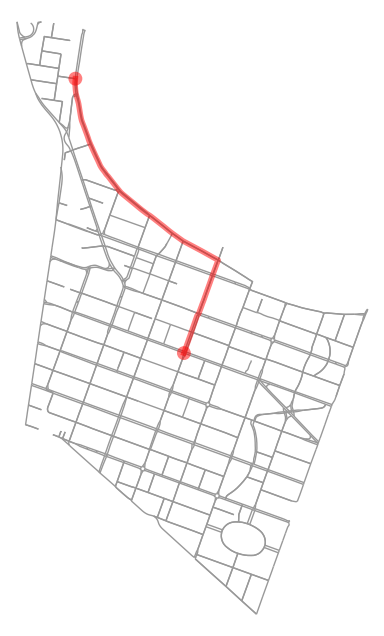

In [82]:
fig, ax = ox.plot_graph_route(
    G,
    route,
    route_linewidth=4,
    node_size=0,
    bgcolor="white"
 )
fig.savefig("../outputs/maps/dijkstra_route.png", dpi=300, bbox_inches="tight")

## Step 12: Compute A* route and save A* map

Run A* with a geometric heuristic, then visualize and save the resulting route.

In [83]:
def heuristic(u, v):
    u_x = G.nodes[u]["x"]
    u_y = G.nodes[u]["y"]
    v_x = G.nodes[v]["x"]
    v_y = G.nodes[v]["y"]
    
    return ((u_x - v_x) ** 2 + (u_y - v_y) ** 2) ** 0.5

In [84]:
route_astar = nx.astar_path(
    G,
    source=start_node,
    target=end_node,
    heuristic=heuristic,
    weight="length"
)

print("A* route found.")
print("Number of nodes in A* route:", len(route_astar))
print("First 10 nodes in A* route:", route_astar[:10])

A* route found.
Number of nodes in A* route: 16
First 10 nodes in A* route: [7755711304, 7755711303, 266090781, 317727339, 3606643577, 3606643590, 263643391, 263576839, 263644743, 317731795]


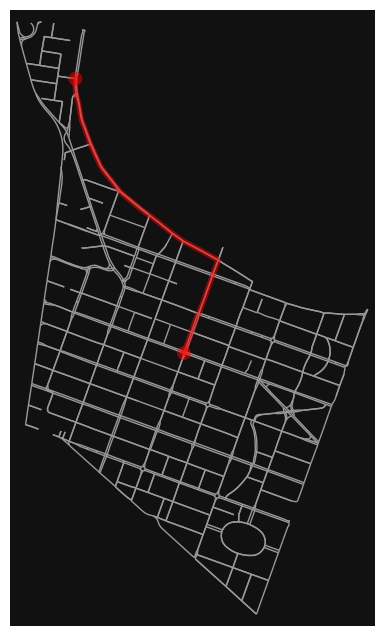

In [85]:
fig, ax = ox.plot_graph_route(
    G,
    route_astar,
    route_linewidth=4,
    node_size=0
 )
fig.savefig("../outputs/maps/astar_route.png", dpi=300, bbox_inches="tight")

In [86]:
astar_distance_m = route_length(G, route_astar)

print(f"A* route length: {astar_distance_m:.2f} meters")
print(f"A* route length: {astar_distance_m / 1000:.2f} km")

A* route length: 2029.28 meters
A* route length: 2.03 km


## Step 13: Benchmark algorithms and export comparison

Measure runtime for Dijkstra and A*, assemble a comparison table, and export it as CSV.

In [87]:
import time

start_time = time.time()

route_dijkstra_test = nx.shortest_path(
    G,
    source=start_node,
    target=end_node,
    weight="length",
    method="dijkstra"
)

dijkstra_runtime = time.time() - start_time

print(f"Dijkstra runtime: {dijkstra_runtime:.6f} seconds")

Dijkstra runtime: 0.000999 seconds


In [88]:
start_time = time.time()

route_astar_test = nx.astar_path(
    G,
    source=start_node,
    target=end_node,
    heuristic=heuristic,
    weight="length"
)

astar_runtime = time.time() - start_time

print(f"A* runtime: {astar_runtime:.6f} seconds")

A* runtime: 0.000000 seconds


In [89]:
import pandas as pd

comparison_df = pd.DataFrame({
    "Algorithm": ["Dijkstra", "A*"],
    "Route Length (m)": [total_distance_m, astar_distance_m],
    "Runtime (s)": [dijkstra_runtime, astar_runtime]
})

comparison_df.to_csv("../outputs/tables/algorithm_comparison.csv", index=False)
comparison_df

,Algorithm,Route Length (m),Runtime (s)
0,Dijkstra,2029.281725,0.000999
1,A*,2029.281725,0.000000
